In [1]:
from dotenv import load_dotenv
import os
load_dotenv()
if os.environ["GOOGLE_API_KEY"]=="" :
    raise ValueError("Please set the GOOGLE_API_KEY environment variable in the .env file.")
else:
    print("GOOGLE_API_KEY is set.")

GOOGLE_API_KEY is set.


In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAI
llm = model = ChatGoogleGenerativeAI(
    model="gemini-3.1-pro-preview",
    temperature=1.0,  # Gemini 3.0+ defaults to 1.0
    max_tokens=None,
    timeout=None,
    max_retries=2,
    # other params...
)

llm



ChatGoogleGenerativeAI(output_version=None, profile={'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-3.1-pro-preview', temperature=1.0, max_retries=2, client=<google.genai.client.Client object at 0x000001E1F62D5F90>, default_metadata=(), model_kwargs={})

In [4]:
llm.invoke("What is the capital of France?")

ChatGoogleGenerativeAIError: Error calling model 'gemini-3.1-pro-preview' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-3.1-pro\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-3.1-pro\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-3.1-pro\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-3.1-pro\nPlease retry in 17.959871615s.', 'status': 'RESOURCE

###Creating a Graph Node

In [6]:
from typing import TypedDict, List

class graph_schema(TypedDict):
    name: str
    messages: str

In [17]:
def welcome(state:graph_schema)-> graph_schema:
    current_name = state["name"]
    curr_messages = state["messages"]
    response = llm.invoke(f"Welcome {current_name}! How can I assist you today? Your previous message was: {curr_messages}").content
    state["messages"] = response
    return state

## Create the state graph

In [18]:
from langgraph.graph import StateGraph, START, END
graph = StateGraph(graph_schema)
#Adding nodes
graph.add_node("welcome", welcome)
#Adding edges
graph.add_edge(START, "welcome")
graph.add_edge("welcome", END)

## Step-4 Compile the graph

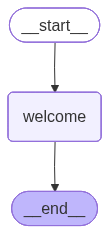

In [19]:
from IPython.display import Image, display
first_state = graph.compile()
Image(first_state.get_graph().draw_mermaid_png())

## STep - 5 Invoke the Graph

In [20]:
first_state.invoke({"name": "Alice", "messages": "Hello!"})

ChatGoogleGenerativeAIError: Error calling model 'gemini-3.1-pro-preview' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-3.1-pro\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-3.1-pro\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-3.1-pro\n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-3.1-pro\nPlease retry in 15.293533682s.', 'status': 'RESOURCE